Audio Deepfake Detection System
Hybrid CNN + XGBoost Model

Splitting dataset into train/val/test...
Splits generated based on speaker identities:
Train: Real=10844, Fake=5913
Val: Real=3946, Fake=3828
Test: Real=5173, Fake=2075

Loading spectrograms...


Loading test/fake: 100%|██████████| 2075/2075 [00:03<00:00, 536.02it/s]



Dataset loaded:
  Training: (16757, 64, 79, 1)
  Validation: (7774, 64, 79, 1)
  Test: (7248, 64, 79, 1)

Training CNN model...
Epoch 1/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.6490 - loss: 0.7037 - val_accuracy: 0.7147 - val_loss: 0.5734 - learning_rate: 0.0010
Epoch 2/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.7577 - loss: 0.5225 - val_accuracy: 0.6744 - val_loss: 0.5811 - learning_rate: 0.0010
Epoch 3/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.8555 - loss: 0.3573 - val_accuracy: 0.8581 - val_loss: 0.3701 - learning_rate: 0.0010
Epoch 4/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.9203 - loss: 0.2244 - val_accuracy: 0.9222 - val_loss: 0.2881 - learning_rate: 0.0010
Epoch 5/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.9411 - loss: 0.1738 - val_accuracy: 0.9401 - val_loss: 0.2372 - learning_rate: 0.0010
Epoch 6/15
262/262 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.9523 - loss: 0.1400 - val_accurac

100%|██████████| 524/524 [00:15<00:00, 34.20it/s]


Extracting embeddings from 7774 samples...


100%|██████████| 243/243 [00:06<00:00, 36.70it/s]

Embedding dimension: (16757, 128)

Training XGBoost classifier...
[0]	validation_0-logloss:0.63371
[1]	validation_0-logloss:0.55671
[2]	validation_0-logloss:0.49433
[3]	validation_0-logloss:0.44315
[4]	validation_0-logloss:0.40056
[5]	validation_0-logloss:0.36428
[6]	validation_0-logloss:0.33342
[7]	validation_0-logloss:0.30684
[8]	validation_0-logloss:0.28449


[9]	validation_0-logloss:0.26518
[10]	validation_0-logloss:0.24821
[11]	validation_0-logloss:0.23332
[12]	validation_0-logloss:0.22044
[13]	validation_0-logloss:0.20946
[14]	validation_0-logloss:0.20001
[15]	validation_0-logloss:0.19176
[16]	validation_0-logloss:0.18433
[17]	validation_0-logloss:0.17812
[18]	validation_0-logloss:0.17254
[19]	validation_0-logloss:0.16803
[20]	validation_0-logloss:0.16413
[21]	validation_0-logloss:0.16069
[22]	validation_0-logloss:0.15754
[23]	validation_0-logloss:0.15536
[24]	validation_0-logloss:0.15337
[25]	validation_0-logloss:0.15152
[26]	validation_0-logloss:0.15021
[27]	validation_0-logloss:0.14898
[28]	validation_0-logloss:0.14833
[29]	validation_0-logloss:0.14766
[30]	validation_0-logloss:0.14685
[31]	validation_0-logloss:0.14622
[32]	validation_0-logloss:0.14655
[33]	validation_0-logloss:0.14645
[34]	validation_0-logloss:0.14675
[35]	validation_0-logloss:0.14723
[36]	validation_0-logloss:0.14739
[37]	validation_0-logloss:0.14785
[38]	validation

100%|██████████| 227/227 [00:06<00:00, 35.21it/s]



Results:
              precision    recall  f1-score   support

        Real       1.00      0.97      0.99      5173
        Fake       0.93      1.00      0.96      2075

    accuracy                           0.98      7248
   macro avg       0.97      0.98      0.97      7248
weighted avg       0.98      0.98      0.98      7248



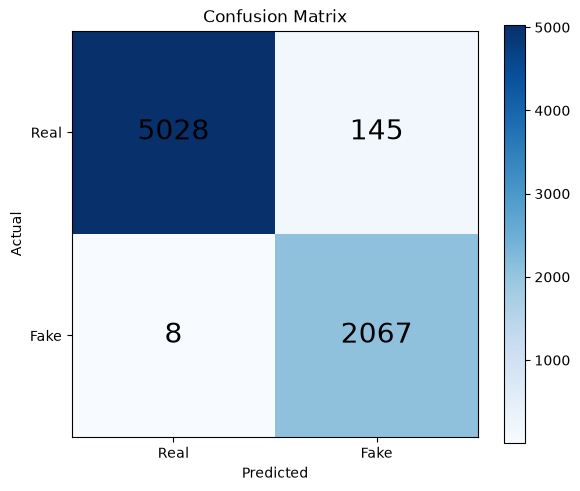

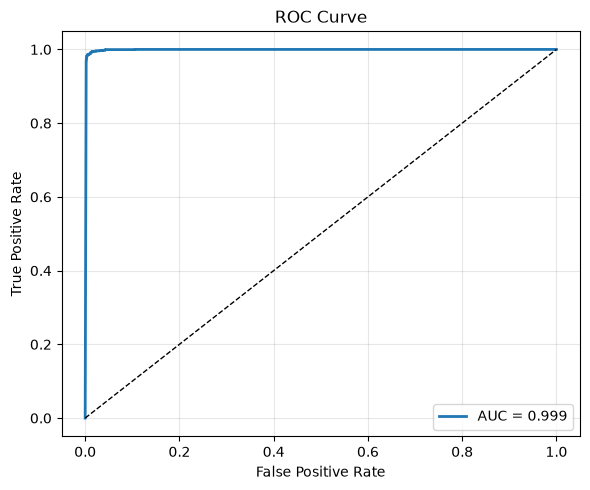


Final AUC Score: 0.9987

Saving models...
Models saved successfully!

Training Complete! Final AUC: 0.9987

Testing predictions on sample audio files

Real Audio Samples:
1. 16321.wav: Real (94.2% confidence)
2. 10988.wav: Real (97.8% confidence)
3. 10750.wav: Real (98.5% confidence)

Fake Audio Samples:
1. 3109.wav: Fake (97.5% confidence)
2. 2217.wav: Fake (97.5% confidence)
3. 13259.wav: Fake (97.5% confidence)

System ready for predictions!


In [5]:
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import xgboost as xgb
from tqdm import tqdm
import pickle
import shutil
import random
import glob

# Load and clean up audio files
def preprocess_audio(audio_path, target_sr=16000, duration=5.0):
    try:
        audio, sr = librosa.load(audio_path, sr=target_sr)
        audio, _ = librosa.effects.trim(audio, top_db=100)
        target_length = int(target_sr * duration)
        if len(audio) < target_length:
            # Fix: Use mode='wrap' instead of zero-padding to avoid artifacts
            pad_length = target_length - len(audio)
            audio = np.pad(audio, (0, pad_length), mode='wrap')
        else:
            audio = audio[:target_length]
        audio = audio / (np.max(np.abs(audio)) + 1e-9)
        return audio, target_sr
    except:
        return None, None

# Convert audio to mel spectrogram
def extract_mel_spectrogram(audio, sr):
    mel_spec = librosa.feature.melspectrogram(
        y=audio, sr=sr, 
        n_mels=64,
        hop_length=1024
    )
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

# Split our dataset into train, validation and test sets
def split_dataset(source_folder, dest_folder):
    print("\nSplitting dataset into train/val/test...")
    for split in ['train', 'val', 'test']:
        for cls in ['real', 'fake']:
            os.makedirs(os.path.join(dest_folder, split, cls), exist_ok=True)
    import pandas as pd
    meta_path = os.path.join(source_folder, 'meta.csv')
    df = pd.read_csv(meta_path)
    
    # Fix: Split by speaker to prevent data leakage
    speakers = df['speaker'].unique().tolist()
    import random
    random.shuffle(speakers)
    
    n_speakers = len(speakers)
    train_end = int(0.7 * n_speakers)
    val_end = int(0.85 * n_speakers)
    
    train_speakers = set(speakers[:train_end])
    val_speakers = set(speakers[train_end:val_end])
    test_speakers = set(speakers[val_end:])
    
    # Assign files to splits based on speaker
    split_counts = {'train': {'real': 0, 'fake': 0}, 'val': {'real': 0, 'fake': 0}, 'test': {'real': 0, 'fake': 0}}
    
    import shutil
    for _, row in df.iterrows():
        speaker = row['speaker']
        filename = row['file']
        label = row['label']
        cls = 'fake' if label == 'spoof' else 'real'
        
        if speaker in train_speakers:
            split = 'train'
        elif speaker in val_speakers:
            split = 'val'
        else:
            split = 'test'
            
        src_path = os.path.join(source_folder, filename)
        if os.path.exists(src_path):
            shutil.copy(src_path, os.path.join(dest_folder, split, cls, filename))
            split_counts[split][cls] += 1
    print("Splits generated based on speaker identities:")
    for split in ['train', 'val', 'test']:
        print(f"{split.capitalize()}: Real={split_counts[split]['real']}, Fake={split_counts[split]['fake']}")

# Load audio files and convert them to spectrograms
def load_spectrograms(data_dir, split):
    X, y = [], []
    
    for label, cls in enumerate(['real', 'fake']):
        folder = os.path.join(data_dir, split, cls)
        files = [f for f in os.listdir(folder) if f.endswith(('.wav', '.mp3', '.flac'))]
        
        for f in tqdm(files, desc=f"Loading {split}/{cls}"):
            audio, sr = preprocess_audio(os.path.join(folder, f))
            if audio is not None:
                spec = extract_mel_spectrogram(audio, sr)
                spec = np.expand_dims(spec, axis=-1)
                X.append(spec)
                y.append(label)
    
    return np.array(X), np.array(y)

# Build our CNN model
def build_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # First convolutional block
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    
    # Second convolutional block
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    
    # Extract features
    x = layers.GlobalAveragePooling2D()(x)
    embeddings = layers.Dense(128, activation='relu', name='embeddings')(x)
    x = layers.Dropout(0.5)(embeddings)
    
    # Final classification
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Train the CNN
def train_cnn(X_train, y_train, X_val, y_val):
    print("\nTraining CNN model...")
    
    model = build_cnn(X_train.shape[1:])
    
    # Define early stopping to prevent overtraining
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3, 
        restore_best_weights=True,
        verbose=1
    )
    
    # Reduce learning rate when stuck
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    return model, history

# Extract embeddings from CNN in batches to avoid memory issues
def extract_embeddings(cnn_model, X, batch_size=32):
    embedding_model = keras.Model(
        inputs=cnn_model.input,
        outputs=cnn_model.get_layer('embeddings').output
    )
    
    embeddings = []
    num_batches = int(np.ceil(len(X) / batch_size))
    
    print(f"Extracting embeddings from {len(X)} samples...")
    for i in tqdm(range(0, len(X), batch_size)):
        batch = X[i:i+batch_size]
        batch_embeddings = embedding_model.predict(batch, verbose=0)
        embeddings.append(batch_embeddings)
    
    return np.vstack(embeddings)

# Train XGBoost classifier on the CNN embeddings
def train_xgboost(X_train, y_train, X_val, y_val):
    print("\nTraining XGBoost classifier...")
    
    model = xgb.XGBClassifier(
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        random_state=42,
        early_stopping_rounds=10
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=True
    )
    
    return model

# Evaluate our hybrid model
def evaluate_hybrid_model(cnn_model, xgb_model, X_test, y_test):
    print("\nEvaluating model on test set...")
    
    # Get embeddings from CNN
    embeddings = extract_embeddings(cnn_model, X_test)
    
    # Make predictions
    y_pred_proba = xgb_model.predict_proba(embeddings)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Print classification results
    print("\nResults:")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues')
    plt.colorbar()
    plt.title('Confusion Matrix')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=20)
    plt.xticks([0, 1], ['Real', 'Fake'])
    plt.yticks([0, 1], ['Real', 'Fake'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png')
    plt.show()
    
    print(f"\nFinal AUC Score: {roc_auc:.4f}")
    return roc_auc

# Main training pipeline
def main():
    print("="*60)
    print("Audio Deepfake Detection System")
    print("Hybrid CNN + XGBoost Model")
    print("="*60)
    
    # Download dataset
        # Use local dataset
    source_folder = 'release_in_the_wild'
    dest_folder = 'processed_data'

    
    # Split the dataset
    split_dataset(source_folder, dest_folder)
    
    # Load spectrograms
    print("\nLoading spectrograms...")
    X_train, y_train = load_spectrograms(dest_folder, 'train')
    X_val, y_val = load_spectrograms(dest_folder, 'val')
    X_test, y_test = load_spectrograms(dest_folder, 'test')
    
    print(f"\nDataset loaded:")
    print(f"  Training: {X_train.shape}")
    print(f"  Validation: {X_val.shape}")
    print(f"  Test: {X_test.shape}")
    
    # Train CNN
    cnn_model, history = train_cnn(X_train, y_train, X_val, y_val)
    
    # Extract embeddings
    print("\nExtracting embeddings...")
    train_embeddings = extract_embeddings(cnn_model, X_train)
    val_embeddings = extract_embeddings(cnn_model, X_val)
    print(f"Embedding dimension: {train_embeddings.shape}")
    
    # Train XGBoost
    xgb_model = train_xgboost(train_embeddings, y_train, val_embeddings, y_val)
    
    # Evaluate
    auc_score = evaluate_hybrid_model(cnn_model, xgb_model, X_test, y_test)
    
    # Save models
    print("\nSaving models...")
    cnn_model.save('cnn_model.keras')
    with open('xgb_model.pkl', 'wb') as f:
        pickle.dump(xgb_model, f)
    print("Models saved successfully!")
    
    print("\n" + "="*60)
    print(f"Training Complete! Final AUC: {auc_score:.4f}")
    print("="*60)
    
    return cnn_model, xgb_model

# Predict if an audio file is real or fake
def predict_audio(audio_path, cnn_model, xgb_model):
    # Load and preprocess audio
    audio, sr = preprocess_audio(audio_path)
    if audio is None:
        return None, None
    
    # Convert to spectrogram
    spec = extract_mel_spectrogram(audio, sr)
    spec = np.expand_dims(spec, axis=(0, -1))
    
    # Get embedding from CNN
    embedding_model = keras.Model(
        inputs=cnn_model.input,
        outputs=cnn_model.get_layer('embeddings').output
    )
    embedding = embedding_model.predict(spec, verbose=0)
    
    # Predict with XGBoost
    prob = xgb_model.predict_proba(embedding)[0, 1]
    
    label = 'Fake' if prob > 0.5 else 'Real'
    confidence = prob * 100 if label == 'Fake' else (1 - prob) * 100
    
    return label, confidence

# Run everything
if __name__ == "__main__":
    # Train the model
    cnn_model, xgb_model = main()
    
    # Test predictions on some sample files
    print("\n" + "="*60)
    print("Testing predictions on sample audio files")
    print("="*60)
    
    real_files = glob.glob('processed_data/test/real/*.wav')[:3]
    fake_files = glob.glob('processed_data/test/fake/*.wav')[:3]
    
    print("\nReal Audio Samples:")
    for i, audio_path in enumerate(real_files, 1):
        label, conf = predict_audio(audio_path, cnn_model, xgb_model)
        filename = os.path.basename(audio_path)
        print(f"{i}. {filename}: {label} ({conf:.1f}% confidence)")
    
    print("\nFake Audio Samples:")
    for i, audio_path in enumerate(fake_files, 1):
        label, conf = predict_audio(audio_path, cnn_model, xgb_model)
        filename = os.path.basename(audio_path)
        print(f"{i}. {filename}: {label} ({conf:.1f}% confidence)")
    
    print("\n" + "="*60)
    print("System ready for predictions!")
    print("="*60)